In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
df = pd.read_csv("Mall_Customers.csv")

In [9]:
print(f'{df.head()}')
print(f'{df.shape}')

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
(200, 5)


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [11]:
df.describe(include='all')

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200,200.000000,200.000000,200.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,112,NaN,NaN,NaN
mean,100.500000,NaN,38.850000,60.560000,50.200000
std,57.879185,NaN,13.969007,26.264721,25.823522
min,1.000000,NaN,18.000000,15.000000,1.000000
25%,50.750000,NaN,28.750000,41.500000,34.750000
50%,100.500000,NaN,36.000000,61.500000,50.000000
75%,150.250000,NaN,49.000000,78.000000,73.000000


In [12]:
print(f'Missing value: {df.isnull().sum().sum()}')
print(f'Duplicates: {df.duplicated().sum()}')

Missing value: 0
Duplicates: 0


<Axes: >

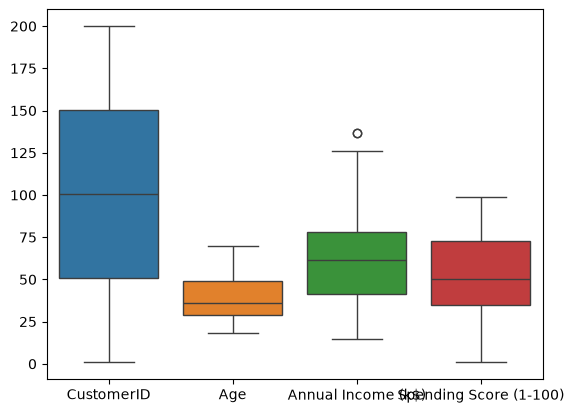

In [13]:
sns.boxplot(df)

In [14]:
df_clean = df.copy()
df_clean.drop(columns='CustomerID', inplace = True)
df_clean['Gender'] = df_clean['Gender'].map({'Male': 0, 'Female': 1})

print(df_clean.head())
print(df_clean.shape)
 


   Gender  Age  Annual Income (k$)  Spending Score (1-100)
0       0   19                  15                      39
1       0   21                  15                      81
2       1   20                  16                       6
3       1   23                  16                      77
4       1   31                  17                      40
(200, 4)


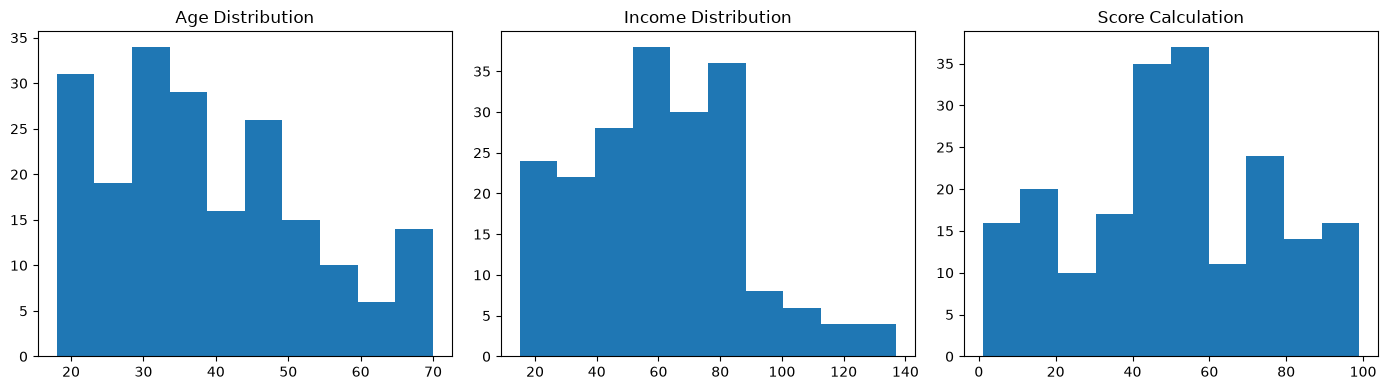

In [22]:
fig, axes = plt.subplots(1,3, figsize=(14, 4))
axes[0].hist(df_clean['Age'])
axes[0].set_title('Age Distribution')

axes[1].hist(df_clean['Annual Income (k$)'])
axes[1].set_title('Income Distribution')

axes[2].hist(df_clean['Spending Score (1-100)'])
axes[2].set_title('Score Calculation')
plt.tight_layout()

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

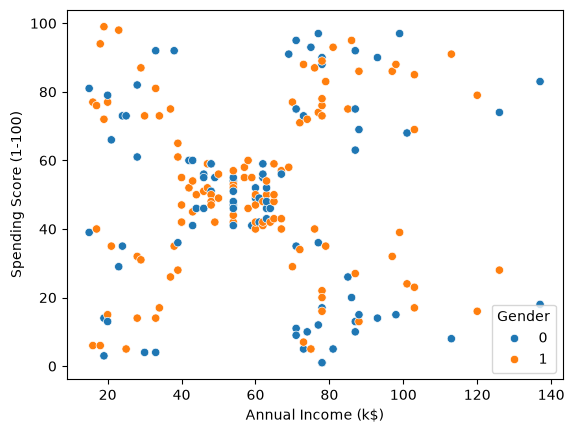

In [23]:
# Income vs spending score - the most important relationship
sns.scatterplot(df_clean,x='Annual Income (k$)', y = 'Spending Score (1-100)', hue='Gender')

<Axes: >

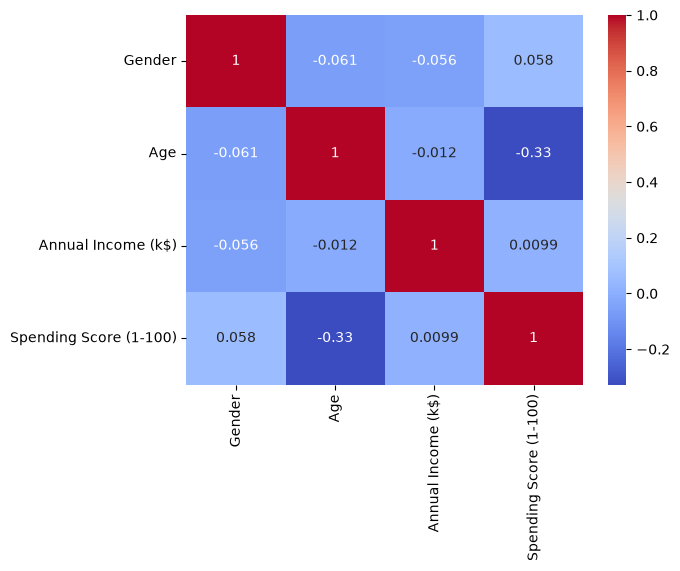

In [27]:
sns.heatmap(df_clean.corr(), annot=True, cmap="coolwarm")

In [31]:
# Feature scaling and Feature selection

X = df_clean[['Annual Income (k$)' ,'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Shape: {X_scaled.shape}")

Shape: (200, 2)


In [53]:
# Train K-Means with K=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_clean["Cluster"] = kmeans.fit_predict(X_scaled)

print("Cluster assignment complete")
print(df_clean["Cluster"].value_counts().sort_index())

Cluster assignment complete
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


In [54]:
# Average values per cluster
profile = df_clean.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean().round(1)
profile["Count"] = df_clean["Cluster"].value_counts().sort_index()
print("Cluster Profiles:")
print(profile)

Cluster Profiles:
          Age  Annual Income (k$)  Spending Score (1-100)  Count
Cluster                                                         
0        42.7                55.3                    49.5     81
1        32.7                86.5                    82.1     39
2        25.3                25.7                    79.4     22
3        41.1                88.2                    17.1     35
4        45.2                26.3                    20.9     23


In [57]:
# Name each cluster based on their profile
cluster_names = {
    0: "Careful Spenders",
    1: "High Value Targets",    
    2: "Budget Shoppers",       
    3: "Impulsive Shoppers",    
    4: "Conservative Wealthy",  
}

print("Suggested cluster names based on income and spending patterns:")
for k, v in cluster_names.items():
    row = profile.loc[k]
    print(f"  Cluster {k}: {v} — Income: {row['Annual Income (k$)']}k | Spending Score: {row['Spending Score (1-100)']}")

Suggested cluster names based on income and spending patterns:
  Cluster 0: Careful Spenders — Income: 55.3k | Spending Score: 49.5
  Cluster 1: High Value Targets — Income: 86.5k | Spending Score: 82.1
  Cluster 2: Budget Shoppers — Income: 25.7k | Spending Score: 79.4
  Cluster 3: Impulsive Shoppers — Income: 88.2k | Spending Score: 17.1
  Cluster 4: Conservative Wealthy — Income: 26.3k | Spending Score: 20.9


In [56]:
final_score = silhouette_score(X_scaled, kmeans.labels_)
print(f"Final Silhouette Score (K=5): {final_score:.3f}")
print()
if final_score >= 0.7:
    print("Excellent — clusters are very well separated")
elif final_score >= 0.5:
    print("Good — clear cluster structure found")
elif final_score >= 0.3:
    print("Acceptable — some overlap between clusters")
else:
    print("Weak — consider different K or features")

Final Silhouette Score (K=5): 0.555

Good — clear cluster structure found


## Summary

**What I did:**
1. Loaded real mall customer data (200 customers, 5 columns)
2. Cleaned data — dropped ID, encoded gender
3. Explored distributions and relationships using charts
4. Used Elbow Method and Silhouette Score to find optimal K
5. Applied K-Means clustering with K=5
6. Profiled each cluster by average income, spending score, and age
7. Named each segment and gave business recommendations

**Key finding:**
The silhouette score of ~0.55 confirms 5 distinct customer segments exist in this data.
The most valuable segment — high income, high spending — should receive the majority of marketing budget.

**Model used:** K-Means Clustering (Scikit-learn)
**Evaluation metric:** Silhouette Score
**Dataset:** Mall Customers — Kaggle